# 05 - Pose density on the real protein (all targets) and the decoy-protein rescore (588689)

**Part A** (all 8 targets, self-filling): where do the ligands sit on each target's actual folded protein? For every folded complex, each chain-A residue's minimum distance to the ligand is measured inside that complex's own coordinates; a residue is in contact when the ligand comes within 5 A. The contact frequency per residue index across poses needs no structural alignment. Re-running picks up any target whose `results/runs/<T>/pose_density/` files exist; others print a `pending:` line.

**Part B** (**588689 only, by design**): the decoy-protein rescore. The decoy experiment was run for this one target only, so nothing in Part B is a cross-target claim.

The paper (Furui and Ohue) does not report pose density or a decoy-protein control, so neither part has a paper value to set beside ours; both are extra analyses of our reproduction. The earlier two-site (Kabsch frame, SAH pocket) analysis of 588689 relied on ligand-centroid files that exist only for 588689; it is kept in `archive_588689/03_pose_density.ipynb` and not regenerated here.

In [1]:

import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")
ROOT = Path("/global/scratch/users/sergiomar10/boltzaff"); sys.path.insert(0, str(ROOT / "pipeline_local"))
import bft_common as bc
bc.style()
TARGETS = bc.TARGETS; SHORT = bc.SHORT
def load_density(t):
    d = ROOT / "results/runs" / t / "pose_density"
    p, z = d / "residue_density.csv", d / "ca_colored.npz"
    miss = [f.name for f in (p, z) if not f.exists()]
    if miss: return None, "missing " + ", ".join(miss)
    try: return (pd.read_csv(p), np.load(z, allow_pickle=True)), ""
    except Exception as e: return None, f"unreadable ({e})"
DATA = {}
for t in TARGETS:
    v, why = load_density(t)
    if v is None: print(f"pending: {t}: pose-density files {why}")
    else: DATA[t] = v
DONE = list(DATA)
print("targets with per-residue pose density:", [SHORT[t] for t in DONE], "of", len(TARGETS))


targets with per-residue pose density: ['588689', '504329', '743445', '485317', '2097', '493091', '2650', '588549'] of 8


# Part A - per-residue ligand density on the real protein

## A0. Ray-traced PyMOL renders (saved as files, not shown here)
Real PyMOL renders (PyMOL 3.1 open-source in the `pymolenv` conda environment, ray traced) of each target's reference structure with the surface coloured by how often the library's predicted poses touch each residue: four views per target (overview, cut-away, pocket, back). To keep this notebook light they are **not embedded**; the PNG files are in `notebooks/figures/<target>_pymol_<view>.png` and the same structures are shown interactively in A0b. This cell renders any missing or outdated view (several minutes per target with 4 CPU threads, cached in `results/analysis/<target>/render/`) and copies the PNGs into `notebooks/figures/`; targets without a pose-density structure print `pending`.

In [2]:
import subprocess, shutil
PYMOL = "/clusterfs/nilah/sergio/miniconda3/envs/pymolenv/bin/python"; RENDER = ROOT / "pipeline_local/render_density_pymol.py"
FIGDIR = ROOT / "notebooks/figures"; FIGDIR.mkdir(exist_ok=True)
for t in TARGETS:
    pdb = ROOT / "results/runs" / t / "pose_density/density_colored.pdb"; od = ROOT / "results/analysis" / t / "render"
    if not pdb.exists(): print(f"pending: {SHORT[t]}: no density_colored.pdb yet"); continue
    names = ["overview", "cutaway", "pocket", "back"]
    try:
        if not all((od / f"{n}.png").exists() and (od / f"{n}.png").stat().st_mtime >= pdb.stat().st_mtime for n in names):
            print(f"rendering {SHORT[t]} with PyMOL (ray tracing, takes a few minutes) ...")
            r = subprocess.run(["nice", PYMOL, str(RENDER), t], capture_output=True, text=True, timeout=3600)
            if r.returncode != 0: print(f"render failed for {SHORT[t]}:", r.stderr[-300:]); continue
        for n in names: shutil.copy(od / f"{n}.png", FIGDIR / f"{t}_pymol_{n}.png")
        print(f"{SHORT[t]}: 4 renders saved in notebooks/figures/")
    except Exception as e: print(f"{SHORT[t]}: render error {e!r}")

588689: 4 renders saved in notebooks/figures/


504329: 4 renders saved in notebooks/figures/


743445: 4 renders saved in notebooks/figures/


485317: 4 renders saved in notebooks/figures/


2097: 4 renders saved in notebooks/figures/


493091: 4 renders saved in notebooks/figures/


2650: 4 renders saved in notebooks/figures/


588549: 4 renders saved in notebooks/figures/


## A0b. The same structures, interactive (rotate, zoom, click)
Live 3D views of the same density-coloured structures (py3Dmol / 3Dmol.js; the view is stored in this notebook and needs internet access to load the 3Dmol script from its CDN when the notebook is opened; if it does not load, the PNG renders in `notebooks/figures/` show the same structures). Cartoon and semi-transparent surface are coloured white to yellow to red by the percent of the library's poses that touch each residue (red = the most-contacted residues, scale saturating at 60% of the maximum), the 10 most-contacted residues are orange sticks with labels, and the green sticks are the ligand of the single reference prediction (it marks the pocket and is not a consensus binding mode). Drag to rotate, scroll to zoom. Change `SURFACE` to False for a cartoon-only view.

In [3]:
import py3Dmol, shutil
SURFACE = True
FIG = ROOT / "notebooks/figures"; FIG.mkdir(exist_ok=True)
for t in TARGETS:                                  # keep the static renders in notebooks/figures/ up to date
    od = ROOT / "results/analysis" / t / "render"
    for v in ("overview", "cutaway", "pocket", "back"):
        if (od / f"{v}.png").exists(): shutil.copy(od / f"{v}.png", FIG / f"{t}_pymol_{v}.png")
def interactive(t):
    pdb = ROOT / "results/runs" / t / "pose_density/density_colored.pdb"; rd = ROOT / "results/runs" / t / "pose_density/residue_density.csv"
    if not pdb.exists(): print(f"pending: {SHORT[t]}: no density_colored.pdb yet"); return
    txt = pdb.read_text(); bmax = max(float(l[60:66]) for l in txt.splitlines() if l.startswith("ATOM")) or 1.0
    cs = {"prop": "b", "gradient": "linear", "colors": ["white", "yellow", "red"], "min": 0, "max": 0.6 * bmax}
    v = py3Dmol.view(width=900, height=650); v.addModel(txt, "pdb")
    v.setStyle({"chain": "A"}, {"cartoon": {"colorscheme": cs}})
    if SURFACE: v.addSurface(py3Dmol.VDW, {"opacity": 0.55, "colorscheme": cs}, {"chain": "A"})
    v.addStyle({"resn": "LIG"}, {"stick": {"colorscheme": "greenCarbon", "radius": 0.25}})
    if rd.exists():
        top = pd.read_csv(rd).sort_values("soft_density", ascending=False).head(10)
        v.addStyle({"chain": "A", "resi": [int(x) for x in top.res_num]}, {"stick": {"colorscheme": "orangeCarbon", "radius": 0.18}})
        for _, r in top.iterrows():
            v.addLabel(f"{str(r.res_name).capitalize()}{int(r.res_num)}", {"fontColor": "black", "backgroundColor": "white", "backgroundOpacity": 0.7, "fontSize": 12, "bold": False, "showBackground": True}, {"chain": "A", "resi": int(r.res_num), "atom": "CA"})
    v.zoomTo({"resn": "LIG"}); v.setBackgroundColor("white")
    print(f"{SHORT[t]}  ({t})"); v.show()
for t in TARGETS:
    try: interactive(t)
    except Exception as e: print(f"{SHORT[t]}: interactive view error {e!r}")

588689  (588689)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

504329  (504329)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

743445  (1053173-743445)


...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

2650  (463203-2650)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

588549  (624273-588549)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## A1. Density profile and backbone, per target
Left: contact frequency versus residue number (one sharp peak = one focused pocket; several peaks = several sites). Right: the real CA trace drawn as a smoothed tube coloured by the same density. Top-contacted residues are printed under each figure. The number of poses behind each profile is not stored; the value printed is inferred as 1 / smallest non-zero contact frequency (a lower bound consistent with the frequency grid, labelled 'inferred').

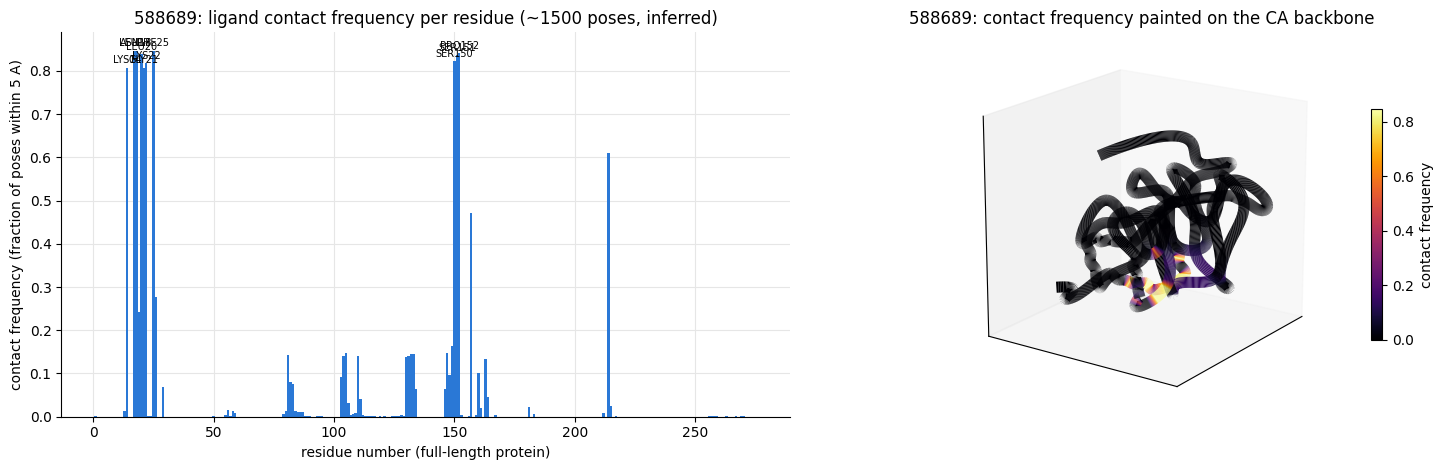

588689: top residues: LEU17(0.85), ASN18(0.85), PHE25(0.85), PRO152(0.84), LEU20(0.84), SER151(0.84), SER150(0.82), LYS22(0.82)


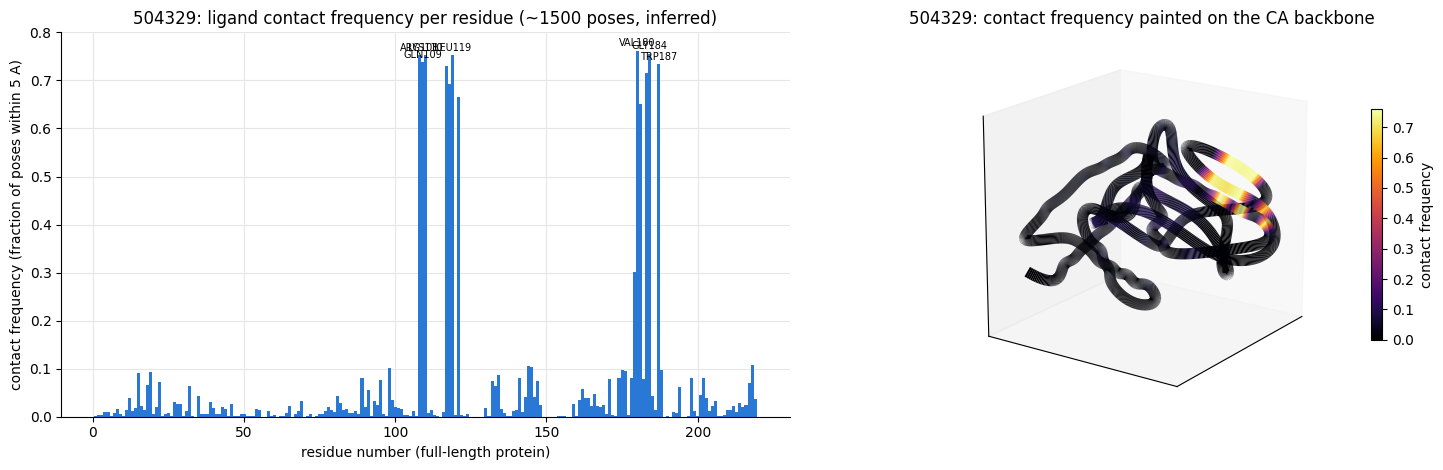

504329: top residues: VAL180(0.76), GLY184(0.76), LEU119(0.75), LYS110(0.75), ARG108(0.75), GLN109(0.74), TRP187(0.73), VAL117(0.73)


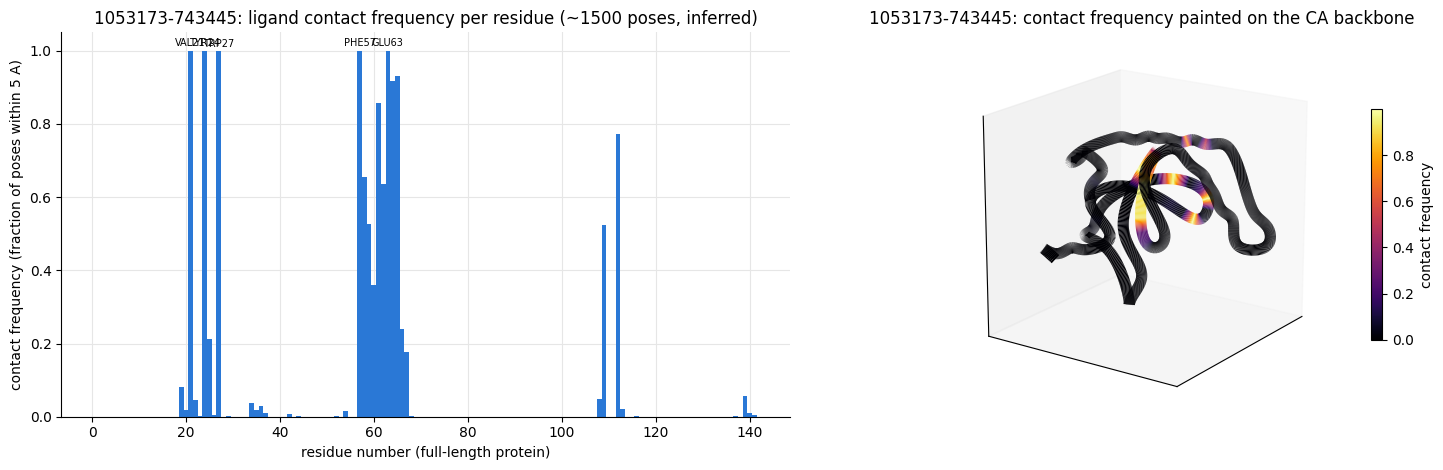

1053173-743445: top residues: VAL21(1.00), PHE57(1.00), GLU63(1.00), TYR24(1.00), TRP27(1.00), ALA65(0.93), ARG64(0.92), ALA61(0.86)


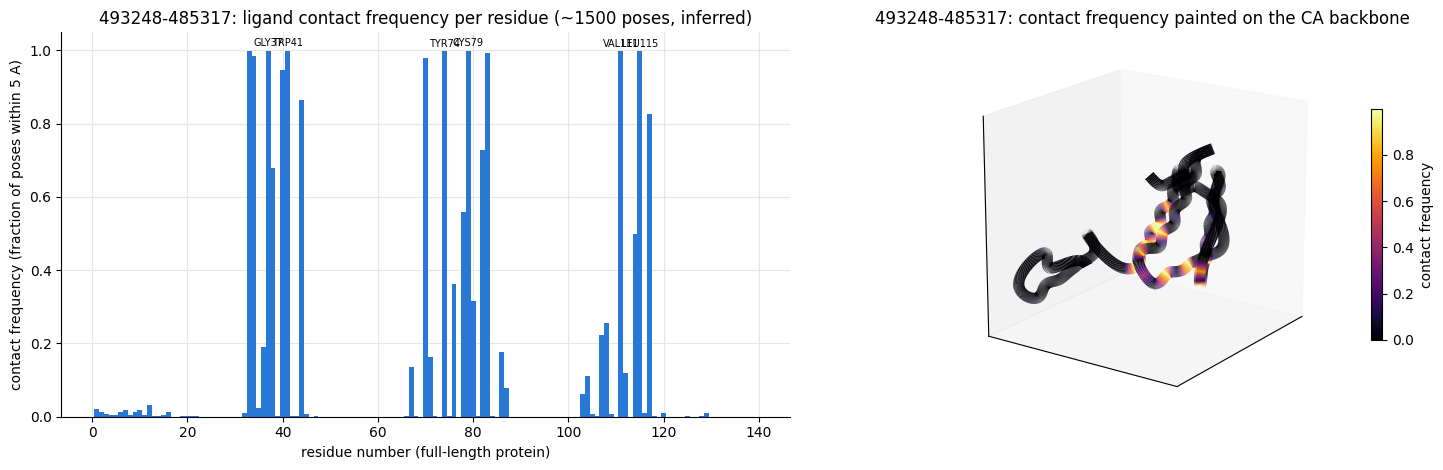

493248-485317: top residues: CYS79(1.00), TRP41(1.00), GLY37(1.00), TYR74(1.00), VAL111(1.00), LEU115(1.00), ARG33(1.00), LEU83(0.99)


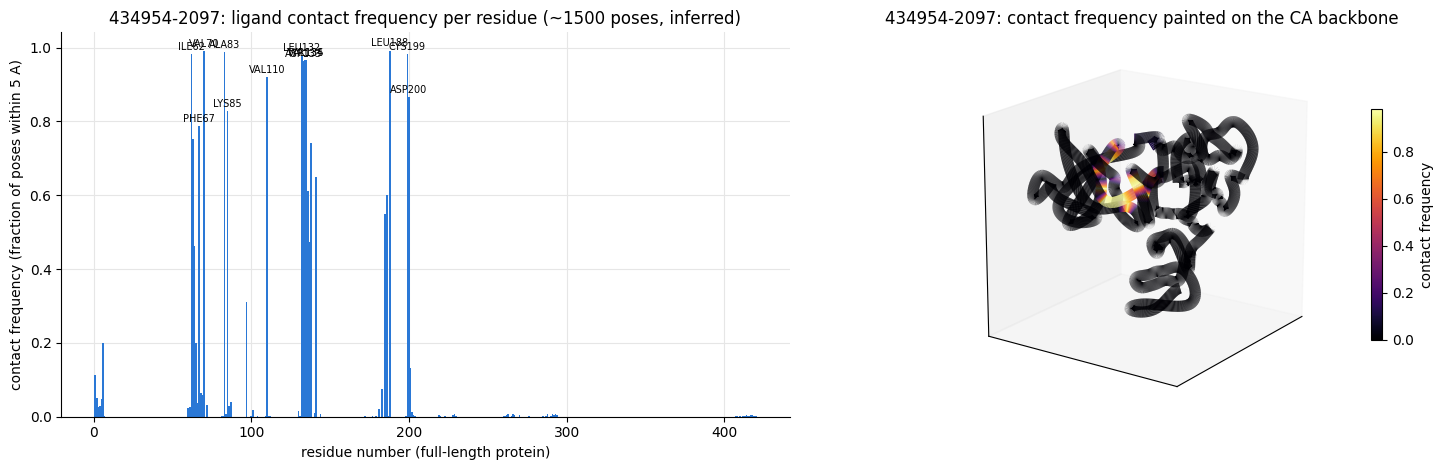

434954-2097: top residues: LEU188(0.99), VAL70(0.99), ALA83(0.99), ILE62(0.98), CYS199(0.98), LEU132(0.98), TYR134(0.97), VAL135(0.97)


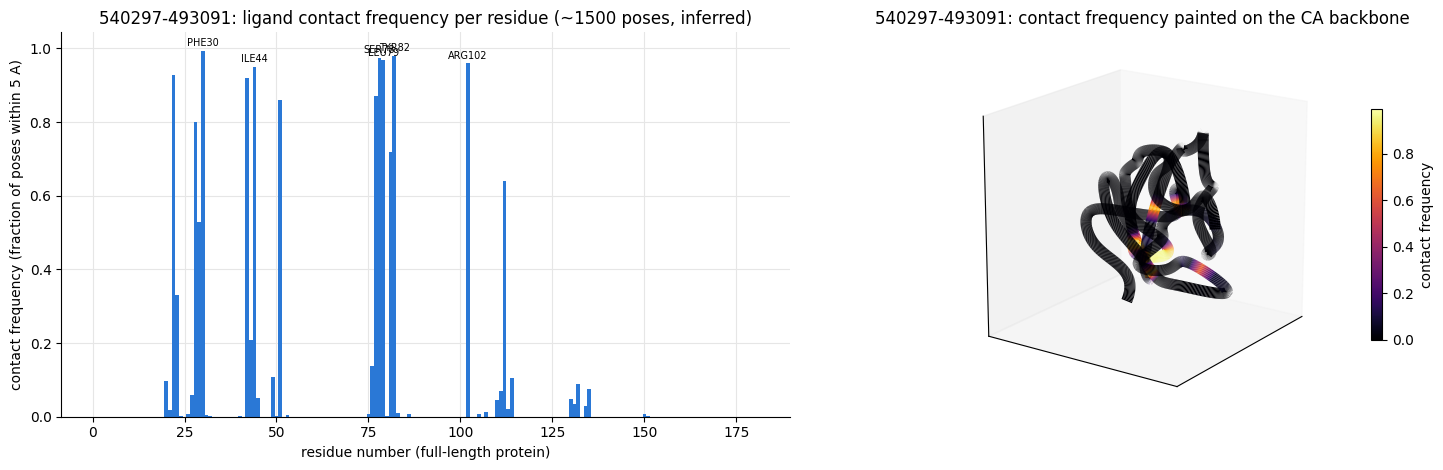

540297-493091: top residues: PHE30(0.99), TYR82(0.98), SER78(0.98), LEU79(0.97), ARG102(0.96), ILE44(0.95), ASP22(0.93), VAL42(0.92)


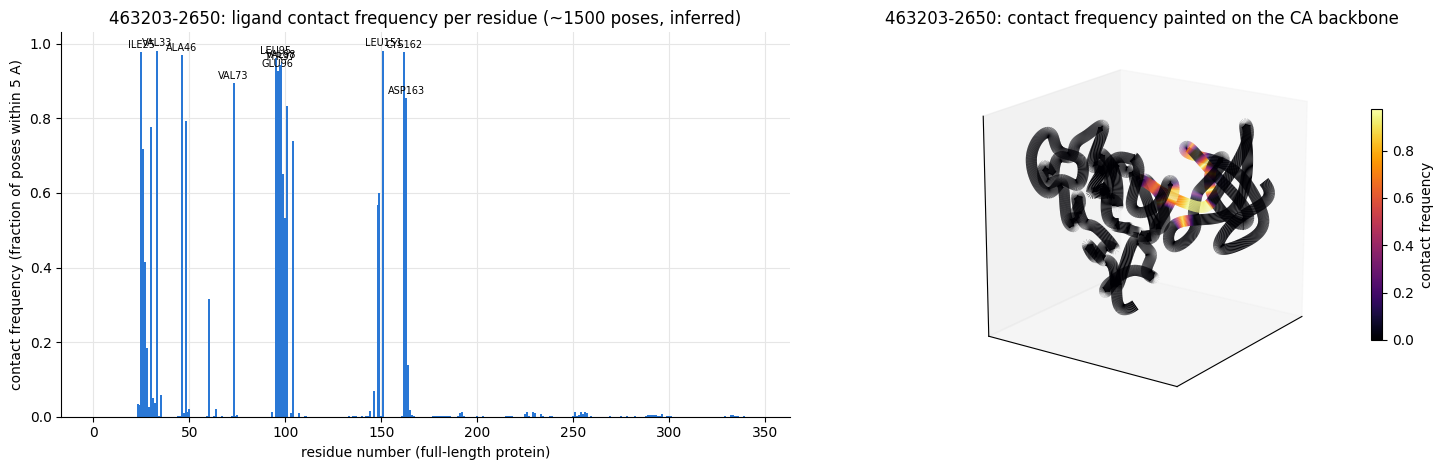

463203-2650: top residues: LEU151(0.98), VAL33(0.98), CYS162(0.98), ILE25(0.98), ALA46(0.97), LEU95(0.96), VAL98(0.95), TYR97(0.94)


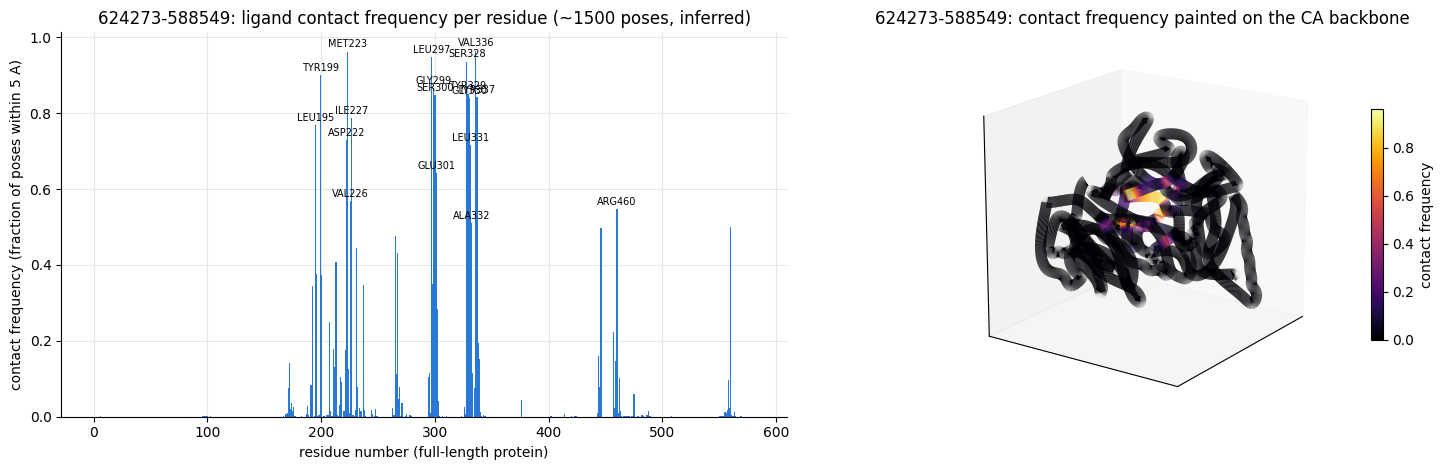

624273-588549: top residues: VAL336(0.96), MET223(0.96), LEU297(0.95), SER328(0.94), TYR199(0.90), GLY299(0.87), TYR329(0.85), SER300(0.85)


In [4]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.interpolate import splprep, splev
def ribbon(ax, ca, dens):
    n = len(ca); k = min(3, n - 1)
    try:
        tck, u = splprep([ca[:, 0], ca[:, 1], ca[:, 2]], s=n * 3.0, k=k); uu = np.linspace(0, 1, n * 14)
        sx, sy, sz = splev(uu, tck); pts = np.array([sx, sy, sz]).T; di = np.interp(uu, np.linspace(0, 1, n), dens)
    except Exception:
        pts = ca; di = dens
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    lc = Line3DCollection(segs, cmap="inferno", linewidths=8); lc.set_array(di[:-1]); ax.add_collection3d(lc)
    mn = pts.min(0); mx = pts.max(0); c = (mn + mx) / 2; rad = (mx - mn).max() / 2 * 1.05
    ax.set_xlim(c[0]-rad, c[0]+rad); ax.set_ylim(c[1]-rad, c[1]+rad); ax.set_zlim(c[2]-rad, c[2]+rad)
    try: ax.set_box_aspect((1, 1, 1))
    except Exception: pass
    return lc
NPOSE = {}
for t in DONE:
    try:
        df, z = DATA[t]; ca = z["ca"]; dens = z["contact_frac"]
        nz = df.contact_frac[df.contact_frac > 0]; NPOSE[t] = int(round(1 / nz.min())) if len(nz) else 0
        fig = plt.figure(figsize=(15, 4.8))
        ax1 = fig.add_subplot(1, 2, 1); ax1.bar(df.res_num, df.contact_frac, width=1.0, color=bc.OUR)
        ax1.set_xlabel("residue number (full-length protein)"); ax1.set_ylabel("contact frequency (fraction of poses within 5 A)")
        ax1.set_title(f"{t}: ligand contact frequency per residue (~{NPOSE[t]} poses, inferred)")
        thr = df.contact_frac.quantile(0.97)
        for _, r in df[df.contact_frac >= thr].iterrows():
            ax1.annotate(f"{r.res_name}{int(r.res_num)}", (r.res_num, r.contact_frac), textcoords="offset points", xytext=(0, 3), ha="center", fontsize=7)
        ax2 = fig.add_subplot(1, 2, 2, projection="3d"); lc = ribbon(ax2, ca, dens)
        ax2.set_title(f"{t}: contact frequency painted on the CA backbone"); ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
        ax2.grid(False); ax2.view_init(elev=18, azim=35); fig.colorbar(lc, ax=ax2, shrink=0.6, label="contact frequency")
        plt.tight_layout(); plt.show()
        top = df.sort_values("contact_frac", ascending=False).head(8)
        print(f"{t}: top residues:", ", ".join(f"{r.res_name}{int(r.res_num)}({r.contact_frac:.2f})" for _, r in top.iterrows()))
    except Exception as e:
        print(f"{t}: plotting failed ({e}); continuing"); plt.close("all")
for t in TARGETS:
    if t not in DONE: print(f"pending: {t}: no pose-density data yet")

## A2. How focused is the binding, per target?
Share of total contact weight held by the top-10 residues, number of residues contacted by at least half of the poses, and the peak residue. Bars are drawn for all 8 targets; targets without data are shown as empty slots labelled pending.

,residues,top10_share,residues_ge_50pct,residues_ge_25pct,peak_residue,peak_freq,poses_inferred
target,,,,,,,
588689,275,0.662,11,13,LEU17,0.847,1500
504329,219,0.553,12,13,VAL180,0.762,1500
1053173-743445,141,0.747,13,14,VAL21,1.000,1500
493248-485317,139,0.567,16,20,GLY37,0.999,1500
434954-2097,420,0.518,19,22,LEU188,0.992,1500
540297-493091,180,0.686,14,15,PHE30,0.994,1500
463203-2650,345,0.520,20,22,VAL33,0.981,1500
624273-588549,580,0.387,19,31,VAL336,0.965,1500


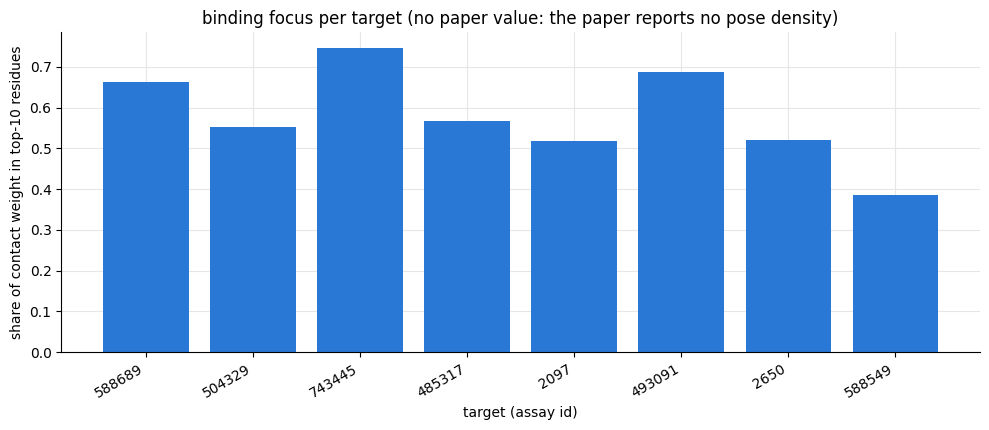

In [5]:
rows = []
for t in DONE:
    try:
        df, _ = DATA[t]; tot = df.contact_frac.sum(); pk = df.loc[df.contact_frac.idxmax()]
        rows.append(dict(target=t, residues=len(df), top10_share=df.contact_frac.nlargest(10).sum() / tot if tot > 0 else np.nan,
                         residues_ge_50pct=int((df.contact_frac >= 0.5).sum()), residues_ge_25pct=int((df.contact_frac >= 0.25).sum()),
                         peak_residue=f"{pk.res_name}{int(pk.res_num)}", peak_freq=pk.contact_frac, poses_inferred=NPOSE.get(t)))
    except Exception as e: print(f"{t}: summary failed ({e})")
FOC = pd.DataFrame(rows).set_index("target") if rows else pd.DataFrame()
if len(FOC):
    display(FOC.round(3))
    fig, ax = plt.subplots(figsize=(10, 4.4)); x = np.arange(len(TARGETS))
    for i, t in enumerate(TARGETS):
        if t in FOC.index: ax.bar(i, FOC.top10_share[t], color=bc.OUR)
        else: ax.bar(i, 0.0); ax.text(i, 0.02, "pending", ha="center", rotation=90, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([SHORT[t] for t in TARGETS], rotation=30, ha="right")
    ax.set_xlabel("target (assay id)"); ax.set_ylabel("share of contact weight in top-10 residues")
    ax.set_title("binding focus per target (no paper value: the paper reports no pose density)"); plt.tight_layout(); plt.show()
else: print("no targets with pose density yet")

## A3. Summary (computed from the tables above)

In [6]:
if len(FOC):
    hi = FOC.top10_share.idxmax(); lo = FOC.top10_share.idxmin()
    order = ", ".join(f"{SHORT[t]} ({v:.2f})" for t, v in FOC.top10_share.sort_values(ascending=False).items())
    txt = (f"- Pose density was available for {len(FOC)} of {len(TARGETS)} targets: {', '.join(SHORT[t] for t in FOC.index)}. "
           f"Pending: {', '.join(SHORT[t] for t in TARGETS if t not in FOC.index) or 'none'}.\n"
           f"- Top-10-residue share of contact weight, highest to lowest: {order}. Most focused: {SHORT[hi]}; least focused: {SHORT[lo]}.\n"
           f"- Residues contacted by >=50% of poses: " + ", ".join(f"{SHORT[t]} {int(FOC.residues_ge_50pct[t])}" for t in FOC.index) + ".\n"
           "- Reading: a high top-10 share with few residues above 50% indicates the library funnels into one pocket; a low share indicates "
           "spread over several sites or a shallow surface. The profile describes where Boltz-2 places ligands; it was **not** linked here to "
           "activity or to score quality (actives vs inactives are not separated in this notebook), and poses per target are a sample of unknown size "
           "(inferred counts above), so small frequency differences between targets should not be over-read. The paper reports no pose density, so no paper comparison is possible.")
    display(Markdown(txt))
else: print("pending: no data")

- Pose density was available for 8 of 8 targets: 588689, 504329, 743445, 485317, 2097, 493091, 2650, 588549. Pending: none.
- Top-10-residue share of contact weight, highest to lowest: 743445 (0.75), 493091 (0.69), 588689 (0.66), 485317 (0.57), 504329 (0.55), 2650 (0.52), 2097 (0.52), 588549 (0.39). Most focused: 743445; least focused: 588549.
- Residues contacted by >=50% of poses: 588689 11, 504329 12, 743445 13, 485317 16, 2097 19, 493091 14, 2650 20, 588549 19.
- Reading: a high top-10 share with few residues above 50% indicates the library funnels into one pocket; a low share indicates spread over several sites or a shallow surface. The profile describes where Boltz-2 places ligands; it was **not** linked here to activity or to score quality (actives vs inactives are not separated in this notebook), and poses per target are a sample of unknown size (inferred counts above), so small frequency differences between targets should not be over-read. The paper reports no pose density, so no paper comparison is possible.

# Part B - decoy-protein rescore (588689 only)

**Scope.** The decoy experiment was run only for target 588689 (1,600 compounds: all 396 held-out actives plus 1,204 random inactives), scored with the standard Boltz-2 protocol against three proteins: the real 588689 protein with its MSA (control), a shuffled-sequence protein without MSA, and an unrelated real protein (target 493091, with its own MSA). Other targets have no decoy data, so this part is explicitly a single-target result and supports no cross-target claim. The subset is 25% active, unlike the library (0.8%), so AUROC is unaffected by the enrichment but AP is not comparable with whole-library AP.

In [7]:
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
D = ROOT / "results/runs/588689/decoy"; HAVE_DECOY = (D / "scores.csv").exists() and (D / "subset.csv").exists()
if not HAVE_DECOY:
    print("decoy scores not found: expected", D / "scores.csv", "and", D / "subset.csv", "- Part B is skipped (it runs for 588689 only).")
else:
    sub = pd.read_csv(D / "subset.csv").set_index("id"); sc = pd.read_csv(D / "scores.csv")
    ARMS = [("real", "real 588689 (control)", "#1baf7a"), ("shuffled", "shuffled sequence, no MSA", "#d62728"), ("other", "unrelated protein (493091)", bc.OUR)]
    W = sc.pivot(index="id", columns="arm", values="prob"); have = [a for a, _, _ in ARMS if a in W.columns]
    if "real" not in have: HAVE_DECOY = False; print("decoy scores found but the real-protein arm is absent; Part B skipped.")
if HAVE_DECOY:
    comp = W[have].dropna().index; y = sub.target_active_v2.astype(int).reindex(comp).values
    print("scored compounds per arm:", {a: int(W[a].notna().sum()) for a in have}, "| in all arms:", len(comp), "of", len(sub))
    print(f"subset: {int(y.sum())} active of {len(y)} ({100*y.mean():.1f}% active)")
    # reference: our No-FT score on the same compounds (from the shared loader) and whole-library context
    S = bc.scores("588689")
    if S is not None:
        Sx = S.set_index("id"); noft = Sx.noft_p.reindex(comp)
        from sklearn.metrics import roc_auc_score as _ra
        print(f"context (full 588689 eval set, {len(S)} compounds): our No-FT AP {bc.average_precision(S.label.values, S.noft_p.values):.3f} vs paper (fixed paper value) {bc.PAPER_BASE.loc['588689','auprc']:.3f}; "
              f"our No-FT AUROC {_ra(S.label.values, S.noft_p.values):.3f} vs paper {bc.PAPER_BASE.loc['588689','auroc']:.3f}; random AP = {bc.RATE['588689']:.4f}. "
              "These are whole-library values, not comparable with the 25%-active subset.")
    else: noft = None; print("pending: 588689 scores not fully available; No-FT reference skipped")
    from rdkit import Chem, RDLogger
    from rdkit.Chem import Descriptors, Crippen
    RDLogger.DisableLog("rdApp.*")
    smi = sub["neut-smiles"].reindex(comp); mols = [Chem.MolFromSmiles(s) for s in smi]
    MW = np.array([Descriptors.MolWt(m) if m else np.nan for m in mols]); LOGP = np.array([Crippen.MolLogP(m) if m else np.nan for m in mols])

scored compounds per arm: {'real': 1600, 'shuffled': 1600, 'other': 1600} | in all arms: 1600 of 1600
subset: 396 active of 1600 (24.8% active)


context (full 588689 eval set, 49685 compounds): our No-FT AP 0.097 vs paper (fixed paper value) 0.096; our No-FT AUROC 0.907 vs paper 0.905; random AP = 0.0080. These are whole-library values, not comparable with the 25%-active subset.


## B1. Ranking quality per arm, with paired bootstrap intervals
AUROC and AP of each arm on the same compounds, with 95% bootstrap intervals over compounds (2,000 resamples). Two single ligand properties (molecular weight, logP; sign chosen on these same data, so slightly optimistic) and our No-FT score are shown for reference. Dashed line: chance.

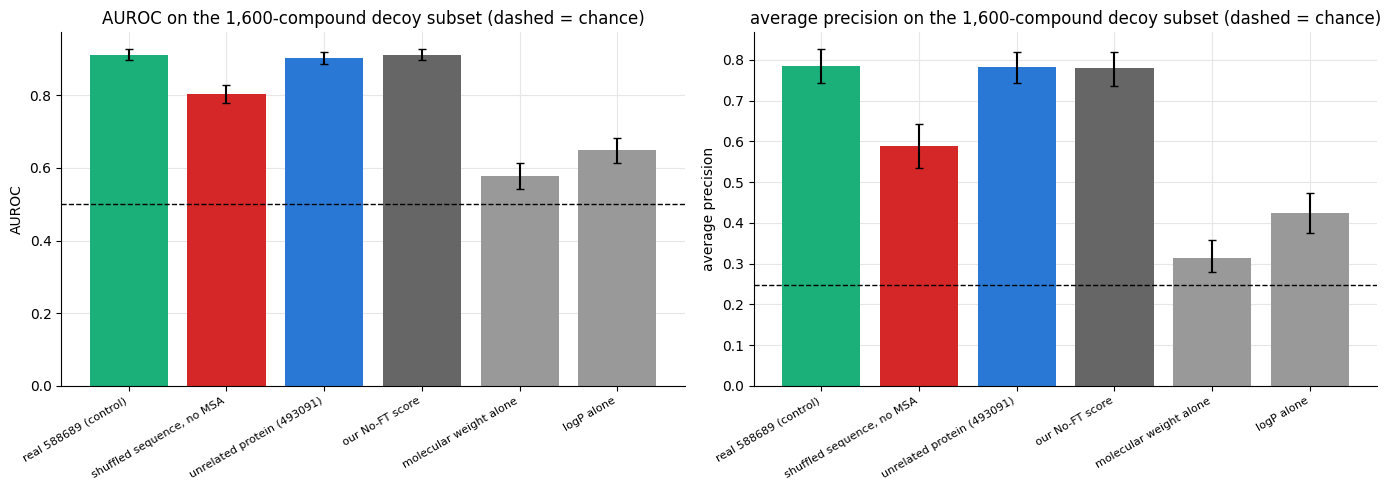

value   lo95   hi95
metric            score                                          
AUROC             real 588689 (control)       0.912  0.896  0.927
                  shuffled sequence, no MSA   0.805  0.779  0.828
                  unrelated protein (493091)  0.904  0.887  0.920
                  our No-FT score             0.912  0.897  0.927
                  molecular weight alone      0.578  0.543  0.613
                  logP alone                  0.650  0.615  0.682
average precision real 588689 (control)       0.786  0.742  0.826
                  shuffled sequence, no MSA   0.588  0.534  0.643
                  unrelated protein (493091)  0.782  0.742  0.820
                  our No-FT score             0.779  0.737  0.818
                  molecular weight alone      0.314  0.278  0.358
                  logP alone                  0.423  0.375  0.474

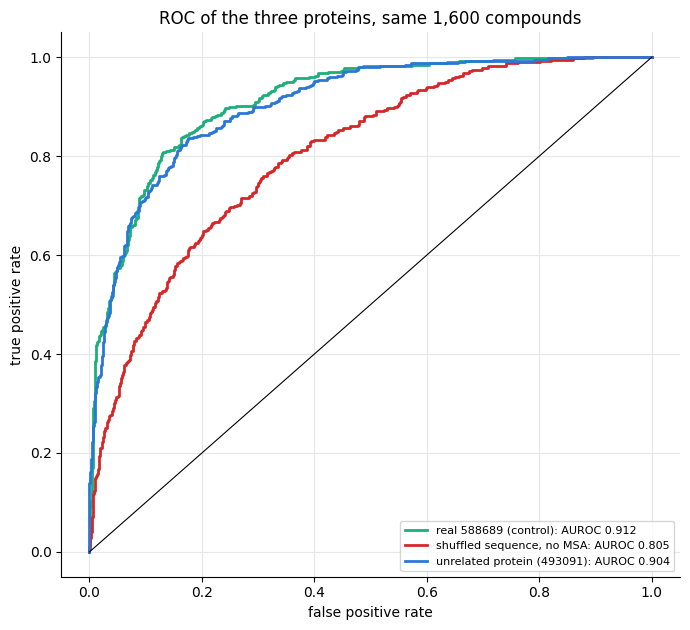

In [8]:
if HAVE_DECOY:
    rng = np.random.default_rng(0); B = 2000; idx = [rng.integers(0, len(y), len(y)) for _ in range(B)]
    lab = {a: l for a, l, _ in ARMS}; col = {a: c for a, _, c in ARMS}
    items = [(lab[a], W.loc[comp, a].values, col[a]) for a in have]
    if noft is not None: items.append(("our No-FT score", noft.values, "#666666"))
    for nm, v in [("molecular weight", MW), ("logP", LOGP)]:
        v = np.nan_to_num(v, nan=np.nanmedian(v)); items.append((nm + " alone", v if roc_auc_score(y, v) >= 0.5 else -v, "#999999"))
    def boot(s, fn): return np.array([fn(y[i], s[i]) for i in idx])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)); out = []
    for ax, (nm, fn, ch) in zip(axes, [("AUROC", roc_auc_score, 0.5), ("average precision", average_precision_score, y.mean())]):
        for i, (l, s, c) in enumerate(items):
            pt = fn(y, s); lo, hi = np.percentile(boot(s, fn), [2.5, 97.5]); ax.bar(i, pt, color=c)
            ax.errorbar(i, pt, yerr=[[pt - lo], [hi - pt]], color="#000000", capsize=3); out.append((nm, l, pt, lo, hi))
        ax.axhline(ch, ls="--", color="#000000", lw=1); ax.set_xticks(range(len(items))); ax.set_xticklabels([l for l, _, _ in items], rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(nm); ax.set_title(f"{nm} on the 1,600-compound decoy subset (dashed = chance)")
    plt.tight_layout(); plt.show()
    T1 = pd.DataFrame(out, columns=["metric", "score", "value", "lo95", "hi95"]).set_index(["metric", "score"]); display(T1.round(3))
    fig, ax = plt.subplots(figsize=(7, 6.4))
    for a in have:
        f, t_, _ = roc_curve(y, W.loc[comp, a].values); ax.plot(f, t_, color=col[a], lw=2, label=f"{lab[a]}: AUROC {roc_auc_score(y, W.loc[comp, a].values):.3f}")
    ax.plot([0, 1], [0, 1], color="#000000", lw=0.8); ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate"); ax.legend(fontsize=8, loc="lower right")
    ax.set_title("ROC of the three proteins, same 1,600 compounds"); plt.tight_layout(); plt.show()

## B2. Does the true protein add anything? Paired differences
AUROC(real) minus AUROC(decoy), bootstrapped over the same resampled compounds. Two comparisons are made, so the interval is shown at 95% and at the Bonferroni-adjusted 97.5% level (alpha 0.05 / 2). An interval containing zero means the difference is not resolved with this sample of compounds; it does not prove equality.

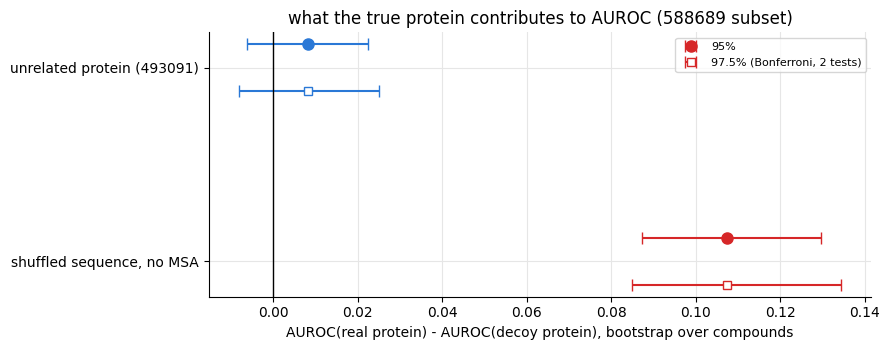

,diff,lo95,hi95,lo_bonf,hi_bonf
"shuffled sequence, no MSA",0.107,0.087,0.130,0.085,0.134
unrelated protein (493091),0.008,-0.006,0.022,-0.008,0.025


In [9]:
if HAVE_DECOY:
    DIFF = {}; fig, ax = plt.subplots(figsize=(9, 3.6))
    decs = [a for a in have if a != "real"]
    for k, a in enumerate(decs):
        sr, sd = W.loc[comp, "real"].values, W.loc[comp, a].values
        d = np.array([roc_auc_score(y[i], sr[i]) - roc_auc_score(y[i], sd[i]) for i in idx]); pt = roc_auc_score(y, sr) - roc_auc_score(y, sd)
        c95 = np.percentile(d, [2.5, 97.5]); cb = np.percentile(d, [1.25, 98.75]); DIFF[a] = (pt, c95, cb)
        ax.errorbar(pt, k + 0.12, xerr=[[pt - c95[0]], [c95[1] - pt]], fmt="o", color=col[a], capsize=4, ms=8, label="95%" if k == 0 else None)
        ax.errorbar(pt, k - 0.12, xerr=[[pt - cb[0]], [cb[1] - pt]], fmt="s", color=col[a], capsize=4, ms=6, mfc="white", label="97.5% (Bonferroni, 2 tests)" if k == 0 else None)
    ax.axvline(0, color="#000000", lw=1); ax.set_yticks(range(len(decs))); ax.set_yticklabels([lab[a] for a in decs]); ax.legend(fontsize=8)
    ax.set_xlabel("AUROC(real protein) - AUROC(decoy protein), bootstrap over compounds"); ax.set_title("what the true protein contributes to AUROC (588689 subset)")
    plt.tight_layout(); plt.show()
    display(pd.DataFrame({lab[a]: dict(diff=v[0], lo95=v[1][0], hi95=v[1][1], lo_bonf=v[2][0], hi_bonf=v[2][1]) for a, v in DIFF.items()}).T.round(3))

## B3. Do per-compound scores agree across proteins?
Spearman correlation of each compound's score between the real arm and each other arm, with bootstrap 95% intervals; also real arm versus the dataset/pipeline scores as a run-to-run reproducibility control.

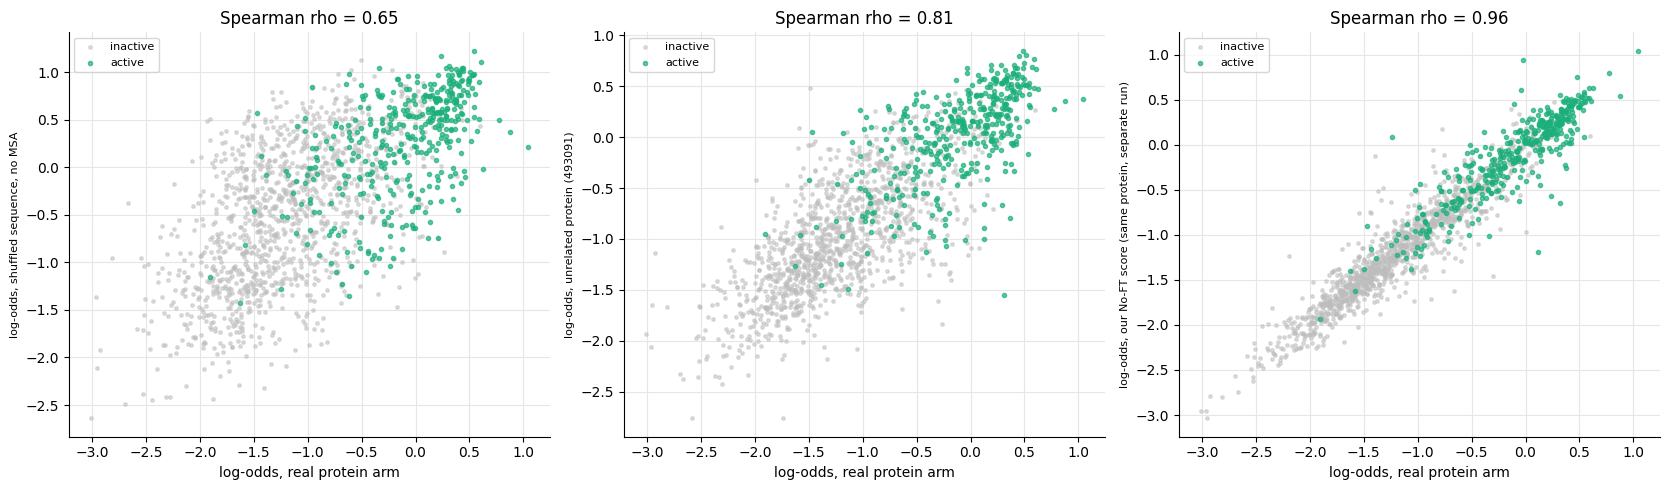

,rho,lo95,hi95
"shuffled sequence, no MSA",0.654,0.619,0.681
unrelated protein (493091),0.809,0.787,0.828
"our No-FT score (same protein, separate run)",0.959,0.951,0.964


In [10]:
if HAVE_DECOY:
    lg = lambda p: np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))
    RHO = {}; pairs = [(a, W.loc[comp, a].values) for a in decs]
    if noft is not None: pairs.append(("noft", noft.values))
    names = {**lab, "noft": "our No-FT score (same protein, separate run)"}
    fig, axes = plt.subplots(1, len(pairs), figsize=(5.6 * len(pairs), 5))
    for ax, (a, z) in zip(np.atleast_1d(axes), pairs):
        x = W.loc[comp, "real"].values; r = stats.spearmanr(x, z)[0]
        bs = np.percentile([stats.spearmanr(x[i], z[i])[0] for i in idx[:500]], [2.5, 97.5]); RHO[a] = (r, bs)
        ax.scatter(lg(x)[y == 0], lg(z)[y == 0], s=6, color="#bdbdbd", alpha=0.5, label="inactive"); ax.scatter(lg(x)[y == 1], lg(z)[y == 1], s=9, color="#1baf7a", alpha=0.7, label="active")
        ax.set_xlabel("log-odds, real protein arm"); ax.set_ylabel(f"log-odds, {names[a]}", fontsize=8); ax.set_title(f"Spearman rho = {r:.2f}"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    display(pd.DataFrame({names[a]: dict(rho=v[0], lo95=v[1][0], hi95=v[1][1]) for a, v in RHO.items()}).T.round(3))

## B4. Proxy: does the real-versus-unrelated gap shrink for compounds close to the training actives?
**This is a proxy, not a test of memorisation.** For each subset compound we compute its maximum ECFP4 Tanimoto similarity (2048 bits, radius 2) to the training compounds used for head fine-tuning at N=300 (`train_ids("588689", 300)`; the N=300 set is the top-ranked 300 by Boltz score, so only those labelled binders are used as the active reference; their number is printed below). The similarity is a property of the compound and the training set, independent of the decoy runs. We then ask, within similarity terciles: (i) the per-compound rank gap |percentile rank(real) - percentile rank(unrelated)|, (ii) the Spearman of real with unrelated, (iii) AUROC(real) - AUROC(unrelated). Note the base Boltz-2 model was not fine-tuned here, so the training actives define a chemotype reference, not data the scorer was trained on. Terciles contain different active fractions, so AUROC is compared only within terciles.

training actives used: 90 (of 300 ids in train_ids_top300); subset compounds with a similarity: 1600
max-Tanimoto to training actives: median 0.23, IQR 0.20-0.28; mean similarity actives 0.34 vs inactives 0.23


,n,n_active,sim_range,mean_rank_gap,gap_lo,gap_hi,rho_real_other,dAUROC_real_minus_other,dAUC_lo,dAUC_hi
tercile,,,,,,,,,,
low similarity,527,56,0.09-0.21,0.143,0.132,0.155,0.748,-0.018,-0.061,0.023
mid similarity,539,100,0.21-0.25,0.138,0.128,0.150,0.768,0.043,0.004,0.079
high similarity,534,240,0.25-0.90,0.115,0.105,0.124,0.842,0.009,-0.013,0.029


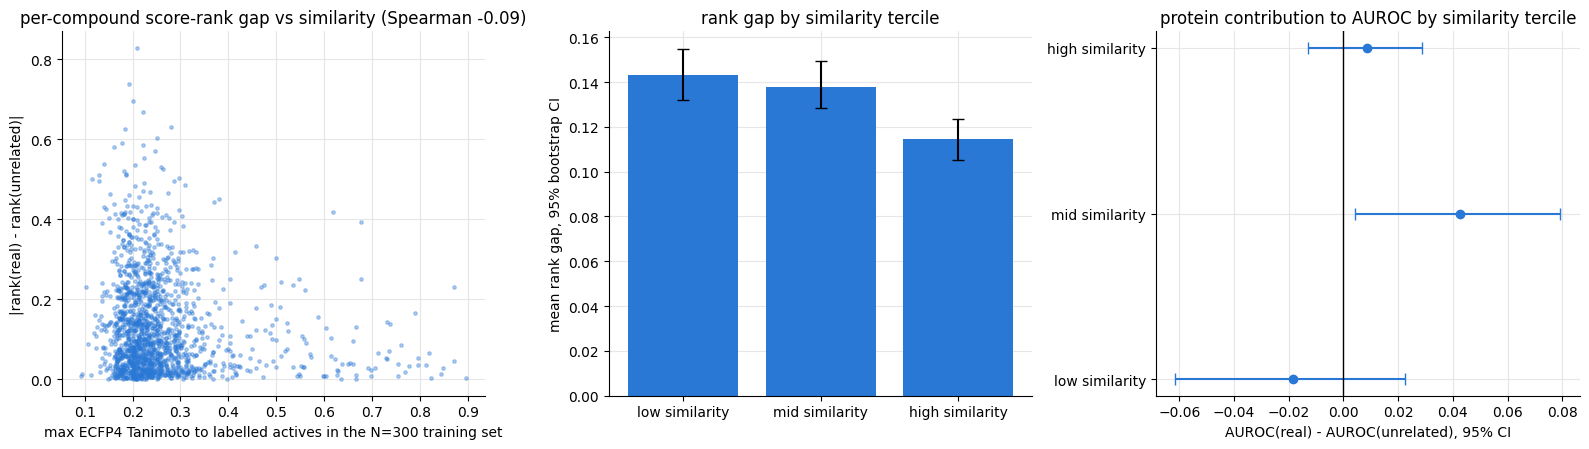

within-class Spearman(similarity, rank gap): actives -0.167 (95% CI -0.263 to -0.062); inactives 0.006 (95% CI -0.047 to 0.063)  [actives are more similar to the training actives and may have a different gap, so the pooled value is confounded by class]
Spearman(similarity, rank gap) = -0.094, 95% bootstrap CI [-0.143, -0.042]  (3 tercile panels + this overall test: Bonferroni threshold 0.05/4 = 0.0125; intervals shown are unadjusted)


In [11]:
if HAVE_DECOY and "other" in have:
    from rdkit.Chem import AllChem, DataStructs
    tr = pd.read_csv(ROOT / "results/runs/588689/ft_inputs_full/ml_table_train.csv")
    ids300 = bc.train_ids("588689", 300)
    if ids300 is None or "is_binder" not in tr.columns: print("pending: training ids/smiles not available; similarity proxy skipped"); SIM = None
    else:
        trs = tr[tr.complex_id.isin(ids300) & (tr.is_binder == 1)]
        fp = lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)
        tfp = [fp(Chem.MolFromSmiles(s)) for s in trs.smiles if Chem.MolFromSmiles(s)]
        ok = np.array([m is not None for m in mols]); sim = np.full(len(comp), np.nan)
        for j, m in enumerate(mols):
            if m is not None: sim[j] = max(DataStructs.BulkTanimotoSimilarity(fp(m), tfp))
        SIM = sim; print(f"training actives used: {len(tfp)} (of {len(ids300)} ids in train_ids_top300); subset compounds with a similarity: {int(np.isfinite(sim).sum())}")
        print(f"max-Tanimoto to training actives: median {np.nanmedian(sim):.2f}, IQR {np.nanpercentile(sim,25):.2f}-{np.nanpercentile(sim,75):.2f}; "
              f"mean similarity actives {np.nanmean(sim[y==1]):.2f} vs inactives {np.nanmean(sim[y==0]):.2f}")
if HAVE_DECOY and "other" in have and SIM is not None:
    pr = lambda v: stats.rankdata(v) / len(v)
    xr, zr = W.loc[comp, "real"].values, W.loc[comp, "other"].values; gap = np.abs(pr(xr) - pr(zr)); g = np.isfinite(SIM)
    rho_gs, _ = stats.spearmanr(SIM[g], gap[g])
    bs_gs = np.percentile([stats.spearmanr(SIM[g][i], gap[g][i])[0] for i in (rng.integers(0, g.sum(), g.sum()) for _ in range(1000))], [2.5, 97.5])
    q = np.nanpercentile(SIM, [100/3, 200/3]); tert = np.digitize(SIM, q); tl = ["low similarity", "mid similarity", "high similarity"]
    rows = []; ii = np.where(g)[0]
    for k in range(3):
        m = g & (tert == k); n = int(m.sum()); yy = y[m]
        rec = dict(tercile=tl[k], n=n, n_active=int(yy.sum()), sim_range=f"{np.nanmin(SIM[m]):.2f}-{np.nanmax(SIM[m]):.2f}", mean_rank_gap=gap[m].mean())
        bts = [rng.integers(0, n, n) for _ in range(1000)]
        gb = [gap[m][b].mean() for b in bts]; rec["gap_lo"], rec["gap_hi"] = np.percentile(gb, [2.5, 97.5])
        rec["rho_real_other"] = stats.spearmanr(xr[m], zr[m])[0]
        if 0 < yy.sum() < n:
            dd = [roc_auc_score(yy[b], xr[m][b]) - roc_auc_score(yy[b], zr[m][b]) for b in bts if 0 < yy[b].sum() < n]
            rec["dAUROC_real_minus_other"] = roc_auc_score(yy, xr[m]) - roc_auc_score(yy, zr[m]); rec["dAUC_lo"], rec["dAUC_hi"] = np.percentile(dd, [2.5, 97.5])
        rows.append(rec)
    TB = pd.DataFrame(rows).set_index("tercile"); display(TB.round(3))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    axes[0].scatter(SIM[g], gap[g], s=6, alpha=0.35, color=bc.OUR); axes[0].set_xlabel("max ECFP4 Tanimoto to labelled actives in the N=300 training set"); axes[0].set_ylabel("|rank(real) - rank(unrelated)|")
    axes[0].set_title(f"per-compound score-rank gap vs similarity (Spearman {rho_gs:.2f})")
    xs = np.arange(3); axes[1].bar(xs, TB.mean_rank_gap, color=bc.OUR); axes[1].errorbar(xs, TB.mean_rank_gap, yerr=[TB.mean_rank_gap - TB.gap_lo, TB.gap_hi - TB.mean_rank_gap], fmt="none", color="#000000", capsize=4)
    axes[1].set_xticks(xs); axes[1].set_xticklabels(tl); axes[1].set_ylabel("mean rank gap, 95% bootstrap CI"); axes[1].set_title("rank gap by similarity tercile")
    if "dAUROC_real_minus_other" in TB: 
        d = TB.dAUROC_real_minus_other.values; axes[2].errorbar(d, xs, xerr=[d - TB.dAUC_lo.values, TB.dAUC_hi.values - d], fmt="o", color=bc.OUR, capsize=4)
    axes[2].axvline(0, color="#000000", lw=1); axes[2].set_yticks(xs); axes[2].set_yticklabels(tl); axes[2].set_xlabel("AUROC(real) - AUROC(unrelated), 95% CI"); axes[2].set_title("protein contribution to AUROC by similarity tercile")
    plt.tight_layout(); plt.show()
    WC = {}
    for v, nm in [(1, "actives"), (0, "inactives")]:
        m = g & (y == v); r_ = stats.spearmanr(SIM[m], gap[m])[0]
        ci = np.percentile([stats.spearmanr(SIM[m][i], gap[m][i])[0] for i in (rng.integers(0, m.sum(), m.sum()) for _ in range(1000))], [2.5, 97.5]); WC[nm] = (r_, ci)
    print("within-class Spearman(similarity, rank gap): " + "; ".join(f"{k} {v[0]:.3f} (95% CI {v[1][0]:.3f} to {v[1][1]:.3f})" for k, v in WC.items()) + "  [actives are more similar to the training actives and may have a different gap, so the pooled value is confounded by class]")
    print(f"Spearman(similarity, rank gap) = {rho_gs:.3f}, 95% bootstrap CI [{bs_gs[0]:.3f}, {bs_gs[1]:.3f}]  (3 tercile panels + this overall test: Bonferroni threshold 0.05/4 = 0.0125; intervals shown are unadjusted)")

## B5. Conclusions (every number below is computed from the data above)

In [12]:
if HAVE_DECOY:
    au = lambda a: roc_auc_score(y, W.loc[comp, a].values); ap = lambda a: average_precision_score(y, W.loc[comp, a].values)
    L = [f"- On the {len(y)} scored compounds ({int(y.sum())} active, {100*y.mean():.0f}% active; chance AP = {y.mean():.2f}), AUROC / AP: " +
         "; ".join(f"{lab[a]} {au(a):.3f} / {ap(a):.3f}" for a in have) + "."]
    for a in decs:
        pt, c95, cb = DIFF[a]; inc = cb[0] <= 0 <= cb[1]
        L.append(f"- AUROC(real) - AUROC({lab[a]}) = {pt:+.3f} (95% CI {c95[0]:+.3f} to {c95[1]:+.3f}; Bonferroni 97.5% CI {cb[0]:+.3f} to {cb[1]:+.3f}): "
                 + ("zero is inside the adjusted interval, so a protein contribution is not resolved." if inc else f"zero is outside the adjusted interval, so the real protein ranks {'better' if pt>0 else 'worse'} by a resolvable margin of about {abs(pt):.2f} AUROC."))
    L.append("- Per-compound Spearman real vs: " + "; ".join(f"{names[a]} {v[0]:.2f} (95% CI {v[1][0]:.2f} to {v[1][1]:.2f})" for a, v in RHO.items()) + ".")
    if "other" in have and SIM is not None:
        L.append(f"- Similarity proxy: Spearman(max Tanimoto to the training actives, |rank(real) - rank(unrelated)|) = {rho_gs:.3f} (95% CI {bs_gs[0]:.3f} to {bs_gs[1]:.3f}); mean rank gap by tercile low/mid/high = "
                 + " / ".join(f"{v:.3f}" for v in TB.mean_rank_gap) + ". " +
                 ("The pooled gap does not resolvably change with similarity." if bs_gs[0] <= 0 <= bs_gs[1] else ("The pooled gap shrinks for compounds more similar to the training actives (small effect)." if rho_gs < 0 else "The pooled gap grows for compounds more similar to the training actives.")) +
                 " Within class: " + "; ".join(f"{k} rho {v[0]:.3f} (95% CI {v[1][0]:.3f} to {v[1][1]:.3f})" for k, v in WC.items()) + "; pooled association may be partly confounded by class, and with 4 related tests the unadjusted intervals should be read with a Bonferroni caveat.")
    L.append("\n**Interpretation (588689 only).** " + ("The ranking of actives is carried mostly by the ligand: scoring the same compounds against an unrelated protein gives "
        f"an AUROC within {abs(DIFF['other'][0]):.3f} of the real protein, and compound-level scores correlate at rho {RHO['other'][0]:.2f}. " if "other" in DIFF else "") +
        ("Replacing the protein by a shuffled sequence without MSA lowers AUROC by " + f"{DIFF['shuffled'][0]:.3f}, but that control also changes the input distribution, so the drop is not a clean measure of protein information. " if "shuffled" in DIFF else "") +
        (("The protein adds little beyond an unrelated protein on this subset as far as AUROC/AP are concerned (difference not resolved). " if "other" in DIFF and DIFF["other"][2][0] <= 0 <= DIFF["other"][2][1] else "The real protein retains a resolvable AUROC advantage over the unrelated protein. ") +
         (f"However, individual compound scores do change with the protein: real-vs-unrelated rho {RHO['other'][0]:.2f} versus {RHO['noft'][0]:.2f} for a rerun on the same protein, so the protein is not irrelevant to the per-compound score, only to the active/inactive ranking." if "other" in RHO and "noft" in RHO else "")))
    L.append("\n**What is NOT tested.** (1) Whether the ligand-only signal reflects memorised training chemotypes or general ligand properties: the similarity analysis is a coarse proxy on one fingerprint and cannot separate the two, and the base model's own training data is not examined. "
             "(2) The unrelated protein has its own MSA and a real fold, so it is not a no-information control; a ligand-driven score could still depend on generic pocket-like features. "
             "(3) The shuffled control alters the input distribution (no MSA, unnatural sequence), so a drop there may reflect out-of-distribution input rather than loss of protein information. "
             "(4) Only one target and one unrelated protein were used, and compounds are the resampling unit, so nothing here generalises across targets. "
             "(5) Head fine-tuning was not applied to the decoy arms, so these results concern base Boltz-2 scoring. "
             "Multiple-comparisons caveat: the two AUROC differences are also reported at Bonferroni 97.5% level; tercile results are exploratory and unadjusted.")
    display(Markdown("\n".join(L)))
else:
    print("decoy scores not found: Part B has no conclusions (588689 decoy experiment data absent).")

- On the 1600 scored compounds (396 active, 25% active; chance AP = 0.25), AUROC / AP: real 588689 (control) 0.912 / 0.786; shuffled sequence, no MSA 0.805 / 0.588; unrelated protein (493091) 0.904 / 0.782.
- AUROC(real) - AUROC(shuffled sequence, no MSA) = +0.107 (95% CI +0.087 to +0.130; Bonferroni 97.5% CI +0.085 to +0.134): zero is outside the adjusted interval, so the real protein ranks better by a resolvable margin of about 0.11 AUROC.
- AUROC(real) - AUROC(unrelated protein (493091)) = +0.008 (95% CI -0.006 to +0.022; Bonferroni 97.5% CI -0.008 to +0.025): zero is inside the adjusted interval, so a protein contribution is not resolved.
- Per-compound Spearman real vs: shuffled sequence, no MSA 0.65 (95% CI 0.62 to 0.68); unrelated protein (493091) 0.81 (95% CI 0.79 to 0.83); our No-FT score (same protein, separate run) 0.96 (95% CI 0.95 to 0.96).
- Similarity proxy: Spearman(max Tanimoto to the training actives, |rank(real) - rank(unrelated)|) = -0.094 (95% CI -0.143 to -0.042); mean rank gap by tercile low/mid/high = 0.143 / 0.138 / 0.115. The pooled gap shrinks for compounds more similar to the training actives (small effect). Within class: actives rho -0.167 (95% CI -0.263 to -0.062); inactives rho 0.006 (95% CI -0.047 to 0.063); pooled association may be partly confounded by class, and with 4 related tests the unadjusted intervals should be read with a Bonferroni caveat.

**Interpretation (588689 only).** The ranking of actives is carried mostly by the ligand: scoring the same compounds against an unrelated protein gives an AUROC within 0.008 of the real protein, and compound-level scores correlate at rho 0.81. Replacing the protein by a shuffled sequence without MSA lowers AUROC by 0.107, but that control also changes the input distribution, so the drop is not a clean measure of protein information. The protein adds little beyond an unrelated protein on this subset as far as AUROC/AP are concerned (difference not resolved). However, individual compound scores do change with the protein: real-vs-unrelated rho 0.81 versus 0.96 for a rerun on the same protein, so the protein is not irrelevant to the per-compound score, only to the active/inactive ranking.

**What is NOT tested.** (1) Whether the ligand-only signal reflects memorised training chemotypes or general ligand properties: the similarity analysis is a coarse proxy on one fingerprint and cannot separate the two, and the base model's own training data is not examined. (2) The unrelated protein has its own MSA and a real fold, so it is not a no-information control; a ligand-driven score could still depend on generic pocket-like features. (3) The shuffled control alters the input distribution (no MSA, unnatural sequence), so a drop there may reflect out-of-distribution input rather than loss of protein information. (4) Only one target and one unrelated protein were used, and compounds are the resampling unit, so nothing here generalises across targets. (5) Head fine-tuning was not applied to the decoy arms, so these results concern base Boltz-2 scoring. Multiple-comparisons caveat: the two AUROC differences are also reported at Bonferroni 97.5% level; tercile results are exploratory and unadjusted.